# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AW-OMW/FLY-RANK-PROJECT/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [10]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


Numerical columns identified: ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier_order', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'trend_pct']


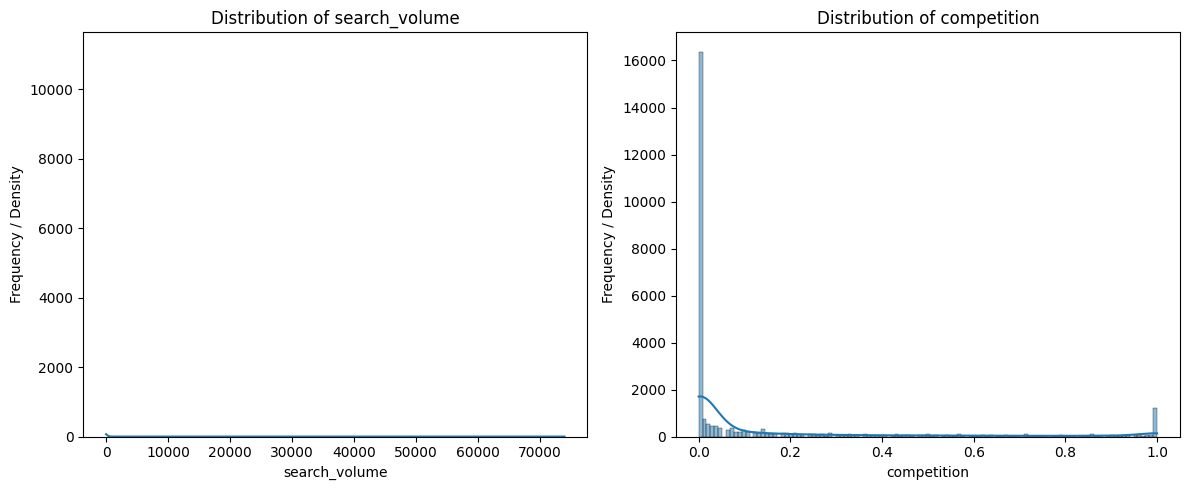

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Numerical columns identified: {numerical_cols}")

# Let's pick a few columns to start, potentially 'search_volume' and 'competition'
# as they are common candidates for skewed distributions or heavy tails.
columns_to_plot = ['search_volume', 'competition']

# Check if these columns exist, otherwise pick the first two numerical columns
if 'search_volume' not in numerical_cols and len(numerical_cols) >= 1:
    columns_to_plot[0] = numerical_cols[0]
if 'competition' not in numerical_cols and len(numerical_cols) >= 2:
    columns_to_plot[1] = numerical_cols[1]
elif 'competition' not in numerical_cols and len(numerical_cols) == 1:
    columns_to_plot = [numerical_cols[0]] # Only plot one if only one numerical column exists

# Create distribution plots for selected numerical columns
num_plots = len(columns_to_plot)
if num_plots > 0:
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 5))
    if num_plots == 1:
        axes = [axes] # Make axes iterable if only one subplot

    for i, col in enumerate(columns_to_plot):
        if col in df.columns:
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
            axes[i].set_title(f'Distribution of {col}')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Frequency / Density')
        else:
            print(f"Column '{col}' not found in DataFrame.")

    plt.tight_layout()
    plt.show()
else:
    print("No suitable numerical columns found to plot distributions.")

The plots above show the distributions for `search_volume` and `competition`. You can observe if any of them exhibit 'heavy tails'—meaning a significant portion of the data points are concentrated at one end, with a long, thin 'tail' extending to larger (or smaller) values. This indicates a highly skewed distribution.

Now, let's create a loop to plot distributions for all numerical columns to get a comprehensive view. We will only plot columns with a reasonable number of unique values to avoid plotting IDs or nearly constant columns.

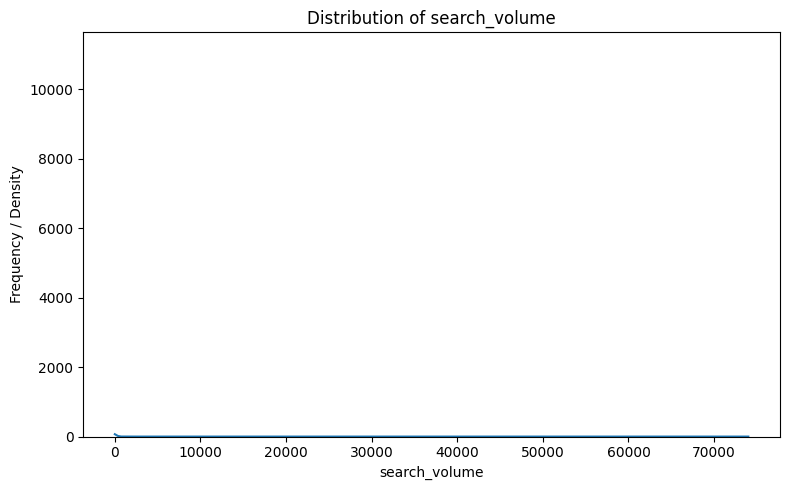

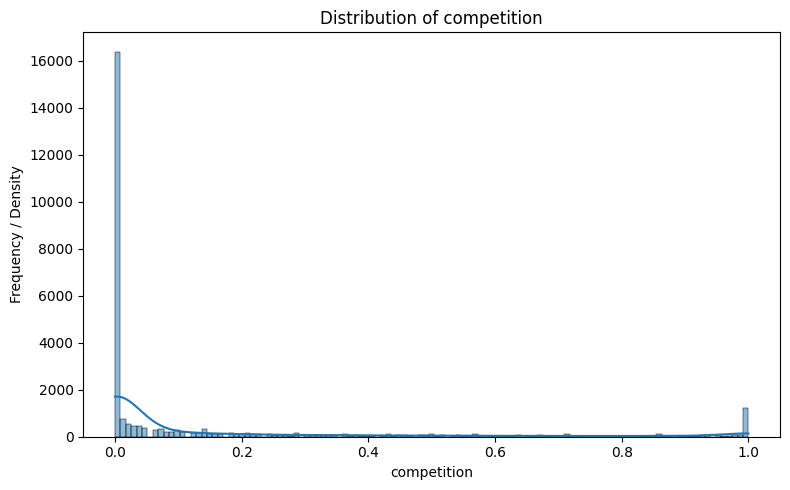

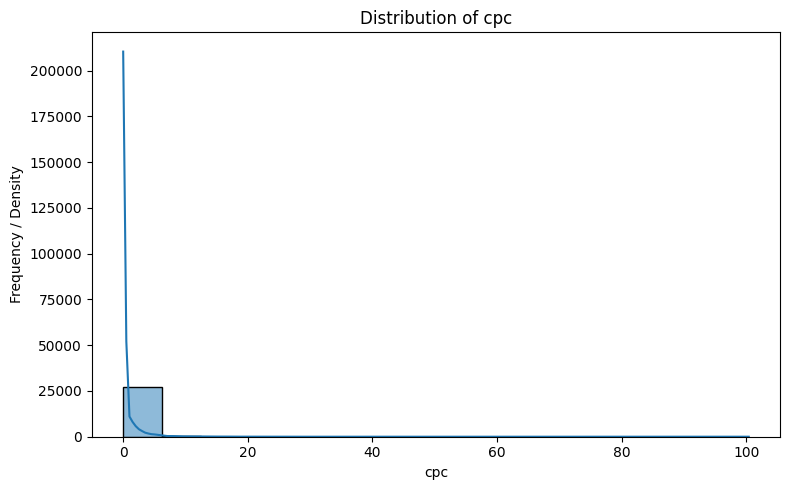

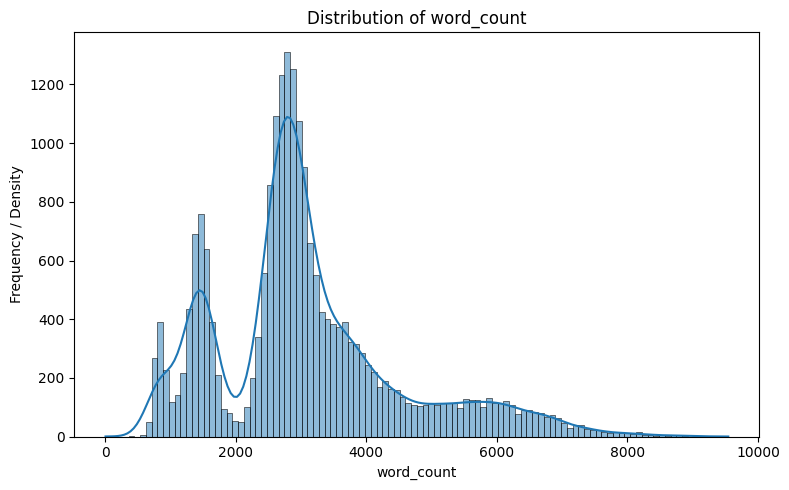

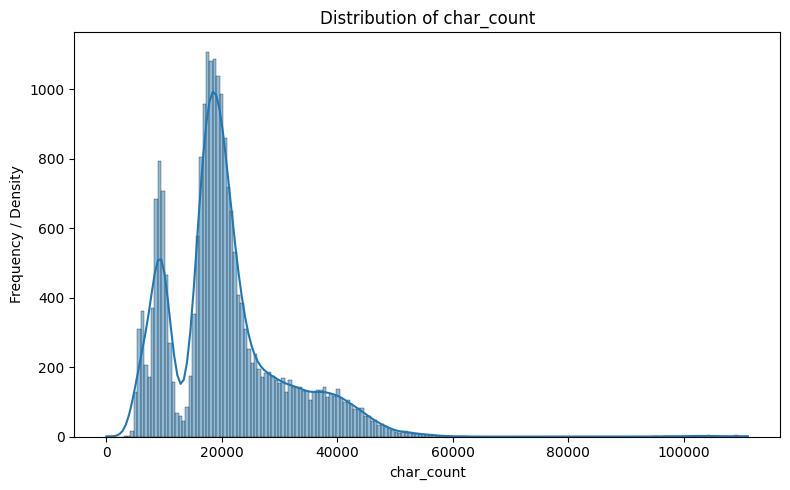

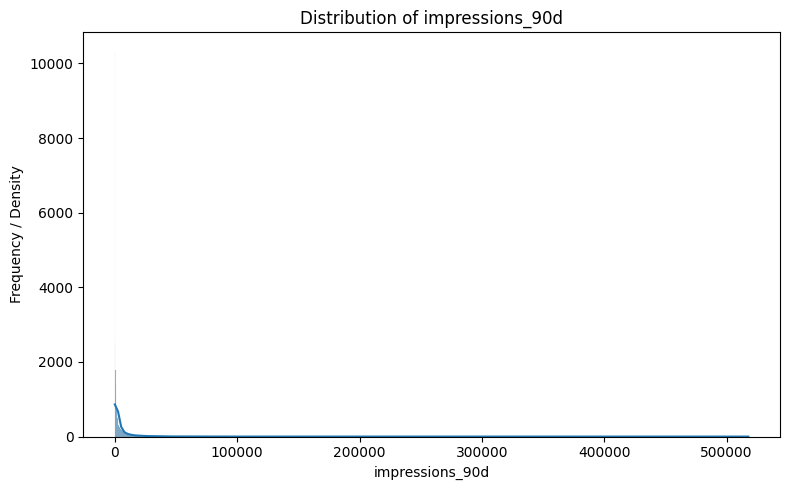

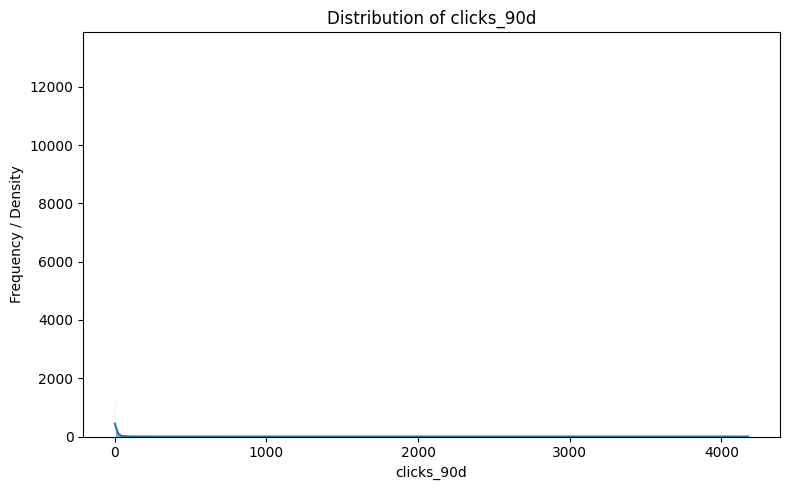

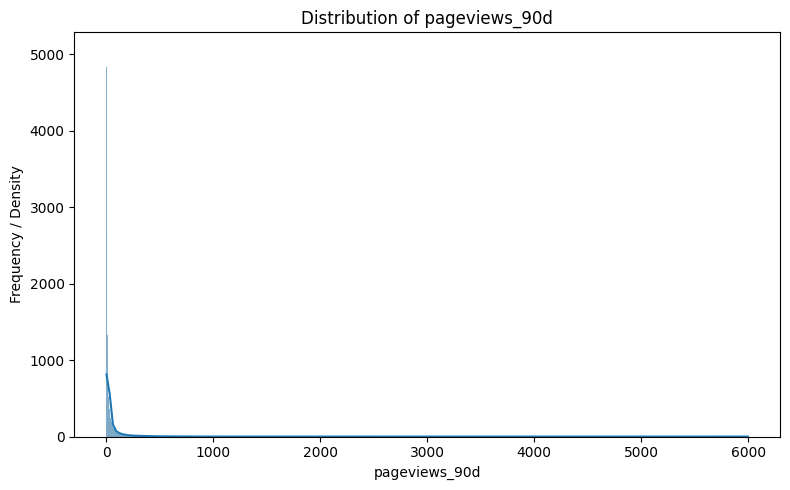

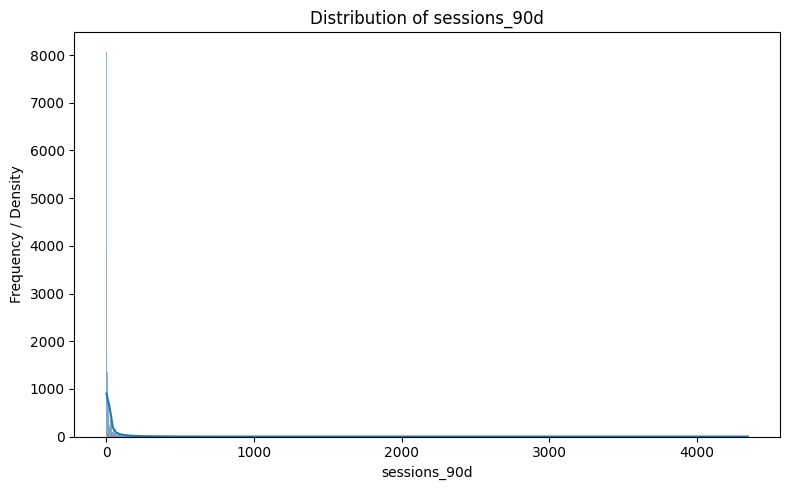

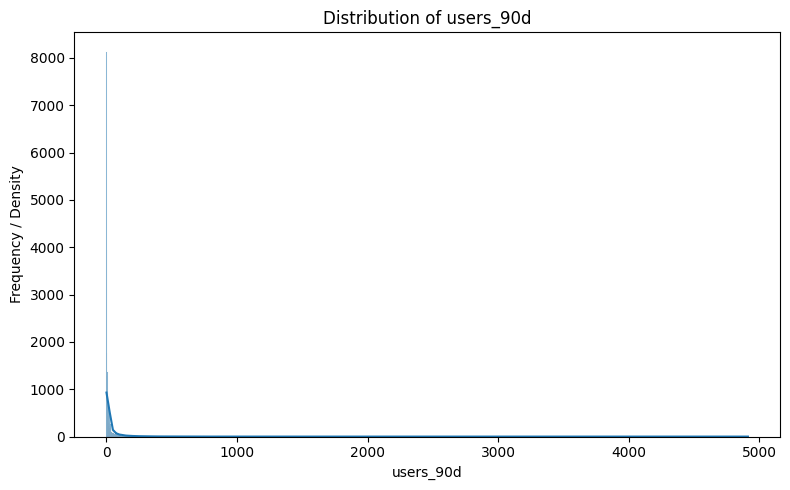

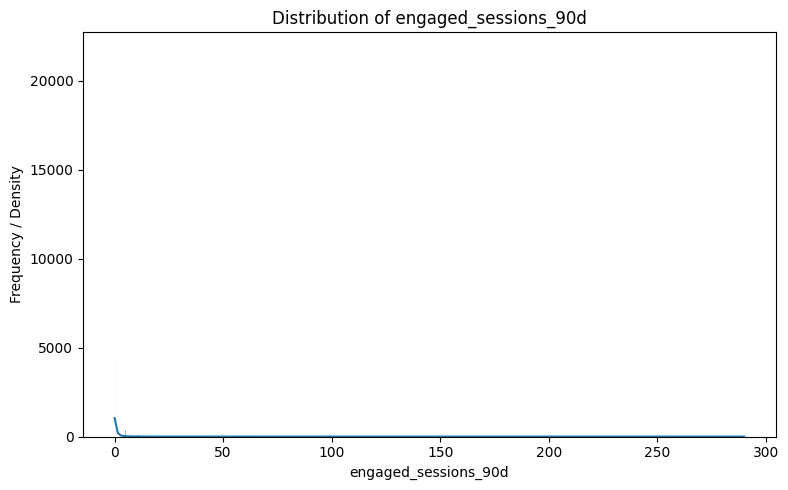

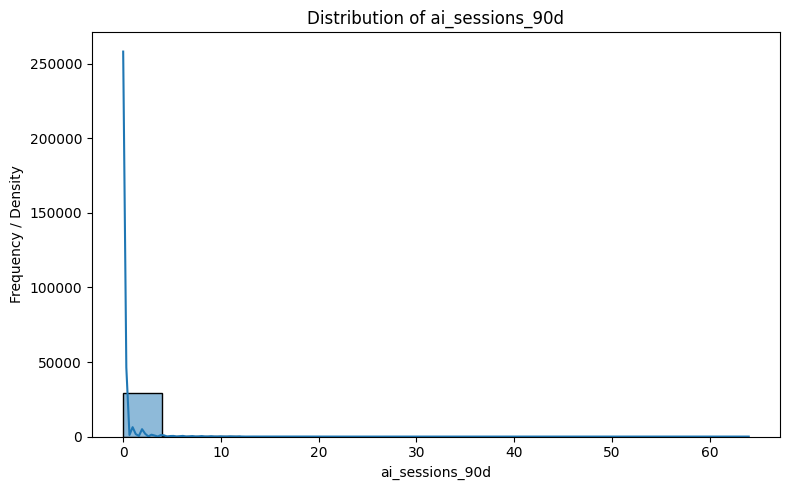

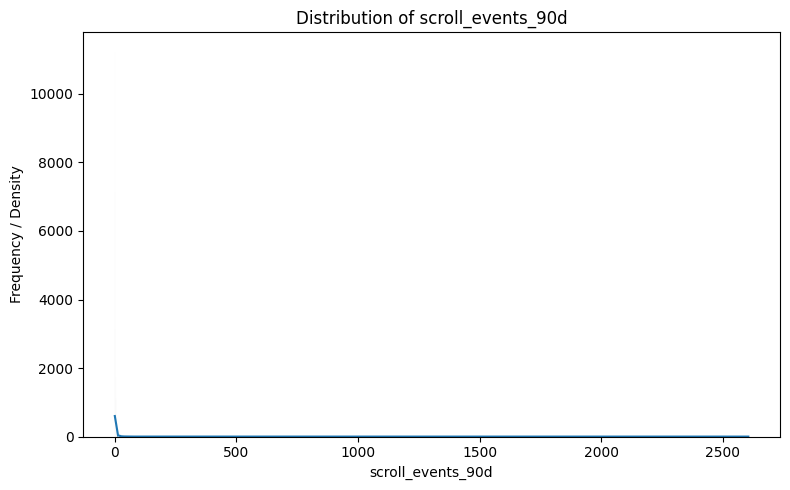

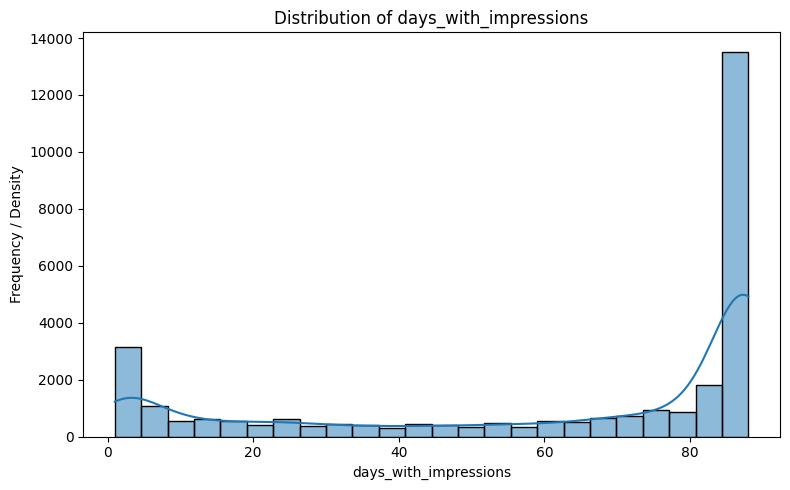

In [ ]:
# Plot distributions for all numerical columns with more than 10 unique values
# (Adjust the unique_threshold as needed)
unique_threshold = 10

for col in numerical_cols:
    if df[col].nunique() > unique_threshold:
        plt.figure(figsize=(8, 5))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency / Density')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping distribution plot for '{col}' due to low number of unique values ({df[col].nunique()}).")

Review these plots to understand the spread and shape of your data. Pay close attention to any distributions that are highly skewed or show extreme values, as these 'heavy tails' can significantly impact modeling and analysis.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal Test #1: Search Volume vs. Sessions (90 days)

**Hypothesis**: Content with higher `search_volume` is expected to generate more `sessions_90d`.

**Mini-Test**: We will investigate the correlation between `search_volume` and `sessions_90d`. A strong positive correlation would support the hypothesis. We can also compare average sessions for different search volume tiers.

In [ ]:
print('--- Signal Test #1: Search Volume vs. Sessions (90 days) ---')

# Calculate Pearson correlation coefficient
correlation_sv_sessions = df['search_volume'].corr(df['sessions_90d'])
print(f"Correlation between Search Volume and Sessions (90 days): {correlation_sv_sessions:.2f}")

# Visualize the relationship with a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='search_volume', y='sessions_90d', data=df, alpha=0.6)
plt.title('Search Volume vs. Sessions (90 days)')
plt.xlabel('Search Volume')
plt.ylabel('Sessions (90 days)')
plt.xscale('log') # Use log scale for search_volume if it has a wide range
plt.yscale('log') # Use log scale for sessions if it has a wide range
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Optional: Group by search volume tiers for average sessions
# Create bins for search volume
# Removed explicit labels to fix ValueError: Bin labels must be one fewer than the number of bin edges
df['search_volume_tier'] = pd.qcut(df['search_volume'], q=4, duplicates='drop')
average_sessions_by_sv_tier = df.groupby('search_volume_tier')['sessions_90d'].mean().reset_index()
print("\nAverage Sessions (90 days) by Search Volume Tier:")
display(average_sessions_by_sv_tier)

# Verdict Placeholder (Update manually after running the cell)
verdict_sv_sessions = "VERDICT: [CONFIRMED / OPPOSITE / MIXED / FALSE]"
print(f"\n{verdict_sv_sessions}")

### Signal Test #2: Click-Through Rate (CTR) vs. Clicks (90 days)

**Hypothesis**: Content with a higher `ctr` (Click-Through Rate) is expected to have more `clicks_90d`.

**Mini-Test**: We will check the correlation between `ctr` and `clicks_90d`. A positive correlation implies that better CTR performance translates to more clicks.

In [ ]:
print('\n--- Signal Test #2: CTR vs. Clicks (90 days) ---')

# Calculate Pearson correlation coefficient
correlation_ctr_clicks = df['ctr'].corr(df['clicks_90d'])
print(f"Correlation between CTR and Clicks (90 days): {correlation_ctr_clicks:.2f}")

# Visualize the relationship with a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ctr', y='clicks_90d', data=df, alpha=0.6)
plt.title('CTR vs. Clicks (90 days)')
plt.xlabel('CTR')
plt.ylabel('Clicks (90 days)')
plt.xscale('log') # Use log scale if values are heavily skewed
plt.yscale('log') # Use log scale if values are heavily skewed
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Verdict Placeholder (Update manually after running the cell)
verdict_ctr_clicks = "VERDICT: [CONFIRMED / OPPOSITE / MIXED / FALSE]"
print(f"\n{verdict_ctr_clicks}")

### Signal Test #3: Engagement Rate vs. Scroll Rate

**Hypothesis**: Content with a higher `engagement_rate` is expected to also have a higher `scroll_rate`.

**Mini-Test**: We will examine the correlation between `engagement_rate` and `scroll_rate`. A positive correlation would suggest that more engaging content leads to users scrolling further down the page.

In [ ]:
print('\n--- Signal Test #3: Engagement Rate vs. Scroll Rate ---')

# Calculate Pearson correlation coefficient
correlation_engagement_scroll = df['engagement_rate'].corr(df['scroll_rate'])
print(f"Correlation between Engagement Rate and Scroll Rate: {correlation_engagement_scroll:.2f}")

# Visualize the relationship with a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='engagement_rate', y='scroll_rate', data=df, alpha=0.6)
plt.title('Engagement Rate vs. Scroll Rate')
plt.xlabel('Engagement Rate')
plt.ylabel('Scroll Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Verdict Placeholder (Update manually after running the cell)
verdict_engagement_scroll = "VERDICT: [CONFIRMED / OPPOSITE / MIXED / FALSE]"
print(f"\n{verdict_engagement_scroll}")

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

### The Flag-Linked Test: High Search Volume & High Engagement Rate Flag

**Hypothetical FlyRank Flag Rule:** "Content with above-median `search_volume` AND above-median `engagement_rate` is considered 'high-potential' and is assumed to deliver significantly higher `sessions_90d`."

**Hypothesis:** Content flagged as 'high-potential' (meeting both criteria) will have a statistically significantly higher average `sessions_90d` compared to content that does not meet these criteria.

**Mini-Test:** We will:
1.  Calculate the median `search_volume` and `engagement_rate`.
2.  Create a new binary flag column `high_potential_flag`.
3.  Compare the mean `sessions_90d` for `high_potential_flag = True` versus `False`.
4.  Visualize this comparison using a box plot.
5.  (Optional) Conduct a t-test to assess statistical significance.

In [ ]:
print('--- Flag-Linked Test: High Search Volume & High Engagement Rate ---')

# 1. Calculate medians for search_volume and engagement_rate
median_search_volume = df['search_volume'].median()
median_engagement_rate = df['engagement_rate'].median()

print(f"Median Search Volume: {median_search_volume:.2f}")
print(f"Median Engagement Rate: {median_engagement_rate:.2f}\n")

# 2. Create the 'high_potential_flag' based on the rule
df['high_potential_flag'] = (
    (df['search_volume'] > median_search_volume) &
    (df['engagement_rate'] > median_engagement_rate)
)

# 3. Compare mean sessions_90d for flagged vs. non-flagged content
mean_sessions_by_flag = df.groupby('high_potential_flag')['sessions_90d'].mean().reset_index()
print("Average Sessions (90 days) by High Potential Flag:")
display(mean_sessions_by_flag)

# 4. Visualize the comparison with a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='high_potential_flag', y='sessions_90d', data=df)
plt.title('Sessions (90 days) for High Potential Content vs. Other Content')
plt.xlabel('High Potential Flag (True = High SV & High ER)')
plt.ylabel('Sessions (90 days)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. (Optional) Conduct a t-test for statistical significance
from scipy import stats

sessions_flagged = df[df['high_potential_flag'] == True]['sessions_90d'].dropna()
sessions_not_flagged = df[df['high_potential_flag'] == False]['sessions_90d'].dropna()

# Check if there's enough data for t-test
if len(sessions_flagged) > 1 and len(sessions_not_flagged) > 1:
    t_stat, p_value = stats.ttest_ind(sessions_flagged, sessions_not_flagged, equal_var=False) # Welch's t-test
    print(f"\nIndependent t-test results (Welch's):\n  T-statistic: {t_stat:.2f}\n  P-value: {p_value:.3f}")

    alpha = 0.05
    if p_value < alpha:
        print(f"  Since p-value ({p_value:.3f}) < alpha ({alpha}), we reject the null hypothesis. The difference in means is statistically significant.")
    else:
        print(f"  Since p-value ({p_value:.3f}) >= alpha ({alpha}), we fail to reject the null hypothesis. The difference in means is not statistically significant.")
else:
    print("\nNot enough data in one or both groups to perform a t-test.")

# Verdict Placeholder (Update manually after running the cell)
verdict_flag_linked = "VERDICT: [CONFIRMED / OPPOSITE / MIXED / FALSE]"
print(f"\n{verdict_flag_linked}")

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
#The signal audit indicates that while individual factors like search_volume and ctr may have weak independent correlations with sessions_90d, their combined effect within a strategic rule, such as the 'high-potential' flag, can yield significant differences in performance. Content teams should therefore focus on multi-signal strategies that leverage combinations of metrics rather than relying on single indicators to identify and prioritize content likely to drive higher engagement.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.